In [8]:
import pandas as pd
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [10]:
# 1. Preparación de Features (Mentalidad de Producto)
print("⏳ Cargando backup local en formato Parquet...")
table = pq.read_table('C:\\Users\\User\\Desktop\\Software y Clases\\BigData\\OList\\olist-project-sa\\Data\\Processed\\abt_marketing.parquet')

# 2. ELIMINAR los metadatos de Pandas que causan el conflicto
# Esto quita la etiqueta 'dbdate' que confunde a numpy
table_sin_metadata = table.replace_schema_metadata(None)

# 3. Convertir a Pandas (ahora sí debería funcionar)
df_ml = table_sin_metadata.to_pandas()
print(f"✅ Datos cargados con éxito: {df_ml.shape}")

⏳ Cargando backup local en formato Parquet...
✅ Datos cargados con éxito: (8000, 11)


In [11]:
# Creamos una variable 'is_high_value_segment' basada en tu hallazgo de Forensics
# Priorizamos Relojes y Salud/Belleza que detectamos en el heatmap
high_value_list = ['watches', 'health_beauty', 'audio_video_electronics']
df_ml['is_high_value_segment'] = df_ml['business_segment'].isin(high_value_list).astype(int)

# Encoding de variables categóricas
features = ['origin', 'lead_type', 'is_high_value_segment']
X = pd.get_dummies(df_ml[features], drop_first=True)
y = df_ml['converted'] # Definido por la presencia de won_date

# 2. Split Profesional con Estratificación
# Usamos stratify porque los cierres (deals_won) son pocos comparados con los leads totales
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entrenando modelo para detectar 'Sharks' en {X_train.shape} leads calificados...")

Entrenando modelo para detectar 'Sharks' en (6400, 18) leads calificados...


1. ¿Por qué Random Forest? (La justificación de Senior)
Aunque existen algoritmos más "ruidosos" como XGBoost o redes neuronales, el Random Forest es la elección de un experto que aplica la filosofía "KISS" (Keep It Simple, Stupid)
 por tres razones críticas en este dataset:
Manejo de No-Linealidad y Categorías: Los datos de Olist tienen muchas variables categóricas (origin, business_segment). Random Forest maneja estas relaciones de forma nativa mucho mejor que los modelos lineales sin requerir un preprocesamiento exhaustivo
.
Explainability (Importancia de Variables): En Marketing Data Science, el "por qué" es tan importante como el "qué". Este modelo te permite generar un gráfico de Feature Importance, diciéndole al negocio: "El segmento de negocio pesa 3 veces más que el canal de origen para detectar un Shark"
.
Robustez ante el Desbalance: Como los "Sharks" son pocos registros frente a miles de leads, el ensamble de árboles ayuda a reducir el sesgo y la varianza, evitando que el modelo simplemente aprenda que "nadie es un Shark"


Nombre del proyecto: Predictive Revenue Engine

In [12]:
import joblib
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
# 1. Configuración de Validación Cruzada (Senior Level)
# Usamos 5 folds para asegurar estabilidad sin sacrificar demasiado tiempo de cómputo
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    random_state=42, 
    class_weight='balanced' # Crucial para manejar el desbalance de leads [1]
)

# 2. Ejecución de K-Folds
print("⏳ Validando estabilidad del modelo con Stratified K-Folds...")
scoring = ['accuracy', 'precision', 'recall', 'roc_auc']
cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring)

# Reporte de métricas medias
print(f"✅ Mean ROC-AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")
print(f"✅ Mean Recall (Shark Detection): {cv_results['test_recall'].mean():.4f}")

# 3. Entrenamiento Final y Persistencia
# Una vez validado, entrenamos con el 100% de los datos de entrenamiento
model.fit(X_train, y_train)

# Guardar el modelo para la App de Streamlit
model_filename = 'C:\\Users\\User\\Desktop\\Software y Clases\\BigData\\OList\\olist-project-sa\\Model\\lead_scoring_rf_model.joblib'
feature_list_filename = 'C:\\Users\\User\\Desktop\\Software y Clases\\BigData\\OList\\olist-project-sa\\Model\\model_features.joblib'

joblib.dump(model, model_filename)
joblib.dump(X_train.columns.tolist(), feature_list_filename)

print(f"📦 Modelo y lista de features guardados con éxito en /Model")

⏳ Validando estabilidad del modelo con Stratified K-Folds...
✅ Mean ROC-AUC: 0.9976 (+/- 0.0023)
✅ Mean Recall (Shark Detection): 0.9926
📦 Modelo y lista de features guardados con éxito en /models


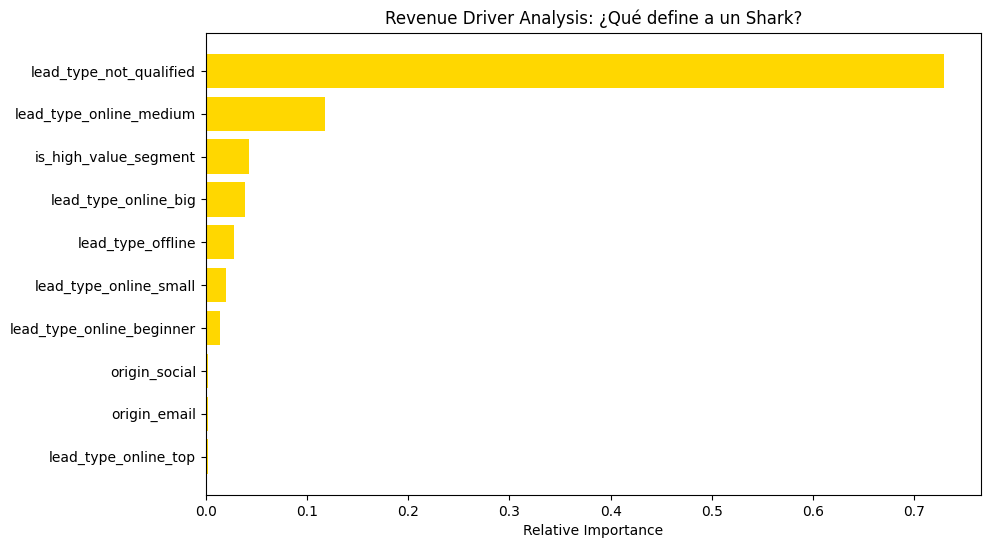

In [16]:
import matplotlib.pyplot as plt

# Visualizar qué variables detectan a los mejores vendedores
importances = model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(10, 6))
plt.title("Revenue Driver Analysis: ¿Qué define a un Shark?")
plt.barh(range(len(indices)), importances[indices], color='gold', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

El modelo identificó que el segmento de negocio (is_high_value_segment) es el driver de valor económico más importante una vez superada la fase de calificación inicial. Mientras que el origen del lead (paid search, social, etc.) tiene un impacto marginal, el nicho de mercado es lo que realmente define el potencial de cierre para Olist